In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Replace with your actual filename
file = '../data/raw/marks_dataset.xlsx'

# Get sheet names
xl = pd.ExcelFile(file)
print("Sheets:", xl.sheet_names)

# Load all sheets into a dictionary so later cells can iterate over `all_sheets`
try:
    # sheet_name=None tells pandas to read all sheets and return a dict
    all_sheets = pd.read_excel(file, sheet_name=None)
    print(f"Loaded {len(all_sheets)} sheets into `all_sheets`")
except Exception as e:
    print("Failed to load sheets from file:", e)
    all_sheets = {}

# Print brief info for each sheet we found
for sheet_name, df in all_sheets.items():
    print(f"\n--- Sheet {sheet_name} ---")
    print("Columns:", df.columns.tolist())
    print("Shape:", df.shape)
    print(df.head(2))

Sheets: ['1', '2', '3', '4', '5', '6']
Loaded 6 sheets into `all_sheets`

--- Sheet 1 ---
Columns: ['Unnamed: 0', 'As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1', 'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8', 'S-I:1', 'S-I', 'S-II:1', 'S-II', 'Final:1', 'Final']
Shape: (37, 21)
   Unnamed: 0   As:1  As:2  As:3  As:4   As:5  As:6  Qz:1  Qz:2  Qz:3  ...  \
0  Weightage:    3.0   3.0   3.0   3.0    3.0   3.0   2.0   2.0   2.0  ...   
1       Total  130.0  70.0  90.0  50.0  120.0  90.0   5.0  15.0  10.0  ...   

   Qz:5  Qz:6  Qz:7  Qz:8  S-I:1   S-I  S-II:1  S-II  Final:1  Final  
0   2.0   2.0   2.0   2.0   15.0  15.0    15.0  15.0     45.0   45.0  
1  10.0   5.0  12.0   2.0   40.0   NaN    40.0   NaN    100.0    NaN  

[2 rows x 21 columns]

--- Sheet 2 ---
Columns: ['Unnamed: 0', 'As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1', 'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8', 'S-I:1', 'S-I', 'S-II:1', 'S-II', 'Final:1', 'Final']
Shape: (31, 21)
   Unnamed

In [25]:
print(" DETAILED STRUCTURE ANALYSIS")

for sheet_name, df in all_sheets.items():
    print(f"\n{'='*80}")
    print(f"SHEET {sheet_name} ")
    print(f"{'='*80}")
    
    print(f"\n Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
    
    
    

 DETAILED STRUCTURE ANALYSIS

SHEET 1 

 Dimensions: 37 rows × 21 columns

SHEET 2 

 Dimensions: 31 rows × 21 columns

SHEET 3 

 Dimensions: 47 rows × 21 columns

SHEET 4 

 Dimensions: 49 rows × 19 columns

SHEET 5 

 Dimensions: 54 rows × 25 columns

SHEET 6 

 Dimensions: 54 rows × 25 columns


In [26]:
# Show first 3 rows (including metadata)
print(f"\n First 3 rows (including metadata):")
print("-" * 80)
print(df.head(3).to_string())
# Extract metadata
print(f"\n  METADATA (Row 0 & 1):")
print("-" * 80)
weightage_row = df.iloc[0]
total_row = df.iloc[1]
    

print("\nTotal Marks Row:")
print(total_row.to_string())
    


 First 3 rows (including metadata):
--------------------------------------------------------------------------------
   Unnamed: 0    As:1    As:2    As:3   As:4  Qz:1  Qz:2  Qz:3  Qz:4  Qz:5  Qz:6  S-I:1  S-I:2  S-I:3   S-I  S-II:1  S-II:2  S-II:3  S-II  Final:1  Final:2  Final:3  Final:4  Final:5  Final
0  Weightage:    3.25    3.25    3.25   3.25   2.0   2.0   2.0   2.0   2.0   2.0    5.0    5.0    5.0  15.0    5.45    4.09    5.45  15.0    16.39      8.1      6.2      6.2      8.1   45.0
1       Total  100.00  120.00  100.00  80.00  10.0  10.0   8.0  10.0  10.0  10.0   20.0   20.0   20.0   NaN   20.00   15.00   20.00   NaN    40.00     20.0     15.0     15.0     20.0    NaN
2        Sr.#     NaN     NaN     NaN    NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN    NaN   NaN     NaN     NaN     NaN   NaN      NaN      NaN      NaN      NaN      NaN    NaN

  METADATA (Row 0 & 1):
--------------------------------------------------------------------------------

Total Marks Row

In [27]:
# Column analysis
print(f"\n COLUMN BREAKDOWN:")
print("-" * 80)
    
columns = df.columns.tolist()
    
# Categorize columns
assignments = [col for col in columns if 'As:' in col]
quizzes = [col for col in columns if 'Qz:' in col]
midterm1 = [col for col in columns if 'S-I' in col]
midterm2 = [col for col in columns if 'S-II' in col]
final = [col for col in columns if 'Final' in col]
project = [col for col in columns if 'Proj' in col]
other = [col for col in columns if col not in assignments + quizzes + 
             midterm1 + midterm2 + final + project]
print(f"\n Assignments ({len(assignments)} columns):")
if assignments:
        for col in assignments:
            weight = weightage_row[col] if col in weightage_row.index else 'N/A'
            total = total_row[col] if col in total_row.index else 'N/A'
            print(f"   {col:15} : Weight: {weight:6}, Total: {total:6}")
    
print(f"\nQuizzes ({len(quizzes)} columns):")
if quizzes:
        for col in quizzes:
            weight = weightage_row[col] if col in weightage_row.index else 'N/A'
            total = total_row[col] if col in total_row.index else 'N/A'
            print(f"   {col:15} : Weight: {weight:6}, Total: {total:6}")


 COLUMN BREAKDOWN:
--------------------------------------------------------------------------------

 Assignments (4 columns):
   As:1            : Weight:   3.25, Total:  100.0
   As:2            : Weight:   3.25, Total:  120.0
   As:3            : Weight:   3.25, Total:  100.0
   As:4            : Weight:   3.25, Total:   80.0

Quizzes (6 columns):
   Qz:1            : Weight:    2.0, Total:   10.0
   Qz:2            : Weight:    2.0, Total:   10.0
   Qz:3            : Weight:    2.0, Total:    8.0
   Qz:4            : Weight:    2.0, Total:   10.0
   Qz:5            : Weight:    2.0, Total:   10.0
   Qz:6            : Weight:    2.0, Total:   10.0


In [21]:
print(f"\n Midterm I  ({len(midterm1)} columns):")
if midterm1:
        for col in midterm1:
            weight = weightage_row[col] if col in weightage_row.index else 'N/A'
            total = total_row[col] if col in total_row.index else 'N/A'
            print(f"   {col:15} : Weight: {weight:6}, Total: {total:6}")
    
print(f"\n Midterm II ({len(midterm2)} columns):")
if midterm2:
        for col in midterm2:
            weight = weightage_row[col] if col in weightage_row.index else 'N/A'
            total = total_row[col] if col in total_row.index else 'N/A'
            print(f"   {col:15} : Weight: {weight:6}, Total: {total:6}")
    
print(f"\n Final Exam ({len(final)} columns):")
if final:
        for col in final:
            weight = weightage_row[col] if col in weightage_row.index else 'N/A'
            total = total_row[col] if col in total_row.index else 'N/A'
            print(f"   {col:15} : Weight: {weight:6}, Total: {total:6}")


 Midterm I  (8 columns):
   S-I:1           : Weight:    5.0, Total:   20.0
   S-I:2           : Weight:    5.0, Total:   20.0
   S-I:3           : Weight:    5.0, Total:   20.0
   S-I             : Weight:   15.0, Total:    nan
   S-II:1          : Weight:   5.45, Total:   20.0
   S-II:2          : Weight:   4.09, Total:   15.0
   S-II:3          : Weight:   5.45, Total:   20.0
   S-II            : Weight:   15.0, Total:    nan

 Midterm II (4 columns):
   S-II:1          : Weight:   5.45, Total:   20.0
   S-II:2          : Weight:   4.09, Total:   15.0
   S-II:3          : Weight:   5.45, Total:   20.0
   S-II            : Weight:   15.0, Total:    nan

 Final Exam (6 columns):
   Final:1         : Weight:  16.39, Total:   40.0
   Final:2         : Weight:    8.1, Total:   20.0
   Final:3         : Weight:    6.2, Total:   15.0
   Final:4         : Weight:    6.2, Total:   15.0
   Final:5         : Weight:    8.1, Total:   20.0
   Final           : Weight:   45.0, Total:    nan


In [18]:
if project:
        print(f"\n Project ({len(project)} columns):")
        for col in project:
            weight = weightage_row[col] if col in weightage_row.index else 'N/A'
            total = total_row[col] if col in total_row.index else 'N/A'
            print(f"   {col:15} → Weight: {weight:6}, Total: {total:6}")
    
if other:
        print(f"\n Other columns ({len(other)}):")
        print(f"   {other}")
    
    # Student data analysis (rows 2 onwards)
student_data = df.iloc[2:].copy()
num_students = len(student_data)
    
print(f"\n STUDENT DATA:")
print("-" * 80)
print(f"   Number of students: {num_students}")
print(f"   Actual data rows: 3 to {df.shape[0]}")
    
    # Check for missing values in student data
numeric_cols = student_data.select_dtypes(include=[np.number]).columns
missing_counts = student_data[numeric_cols].isnull().sum()
    
if missing_counts.sum() > 0:
        print(f"\n  Missing values detected:")
        for col, count in missing_counts[missing_counts > 0].items():
            pct = (count / num_students * 100)
            print(f"   {col:15} = {count:4} missing ")
else:
        print(f"\n✓ No missing values in numeric columns")


 Other columns (1):
   ['Unnamed: 0']

 STUDENT DATA:
--------------------------------------------------------------------------------
   Number of students: 52
   Actual data rows: 3 to 54

  Missing values detected:
   As:1            =    4 missing 
   As:2            =    4 missing 
   As:3            =    3 missing 
   As:4            =    5 missing 
   Qz:1            =    2 missing 
   Qz:2            =    1 missing 
   Qz:3            =    1 missing 
   Qz:4            =    2 missing 
   Qz:5            =    7 missing 
   Qz:6            =    6 missing 
   S-I:1           =    1 missing 
   S-I:2           =    1 missing 
   S-I:3           =    1 missing 
   S-I             =    1 missing 
   S-II:1          =    1 missing 
   S-II:2          =    1 missing 
   S-II:3          =    1 missing 
   S-II            =    2 missing 
   Final:1         =    1 missing 
   Final:2         =    1 missing 
   Final:3         =    1 missing 
   Final:4         =    1 missing 
   Final:5 

For our predictions, we'll use the WEIGHTED columns as targets:
   
   RQ1 Target: 'S-I'     (Weighted Midterm I score)
   RQ2 Target: 'S-II'    (Weighted Midterm II score)  
   RQ3 Target: 'Final'   (Weighted Final exam score)

In [30]:
# ============================================================================
#  VERIFY TARGET COLUMNS EXIST IN ALL SHEETS
# ============================================================================
print("\n" + "="*80)
print("1.4 VERIFYING TARGET COLUMNS")
print("="*80)

target_verification = {
    'S-I': [],
    'S-II': [],
    'Final': []
}

for sheet_name, df in all_sheets.items():
    for target in target_verification.keys():
        if target in df.columns:
            target_verification[target].append(f"Sheet {sheet_name} ")

print("\n Target Column Availability:")
for target, availability in target_verification.items():
    print(f"\n{target}:")
    for status in availability:
        print(f"   {status}")


1.4 VERIFYING TARGET COLUMNS

 Target Column Availability:

S-I:
   Sheet 1 
   Sheet 2 
   Sheet 3 
   Sheet 4 
   Sheet 5 
   Sheet 6 

S-II:
   Sheet 1 
   Sheet 2 
   Sheet 3 
   Sheet 4 
   Sheet 5 
   Sheet 6 

Final:
   Sheet 1 
   Sheet 2 
   Sheet 3 
   Sheet 4 
   Sheet 5 
   Sheet 6 



 CREATING VISUALIZATION OF DATA STRUCTURE


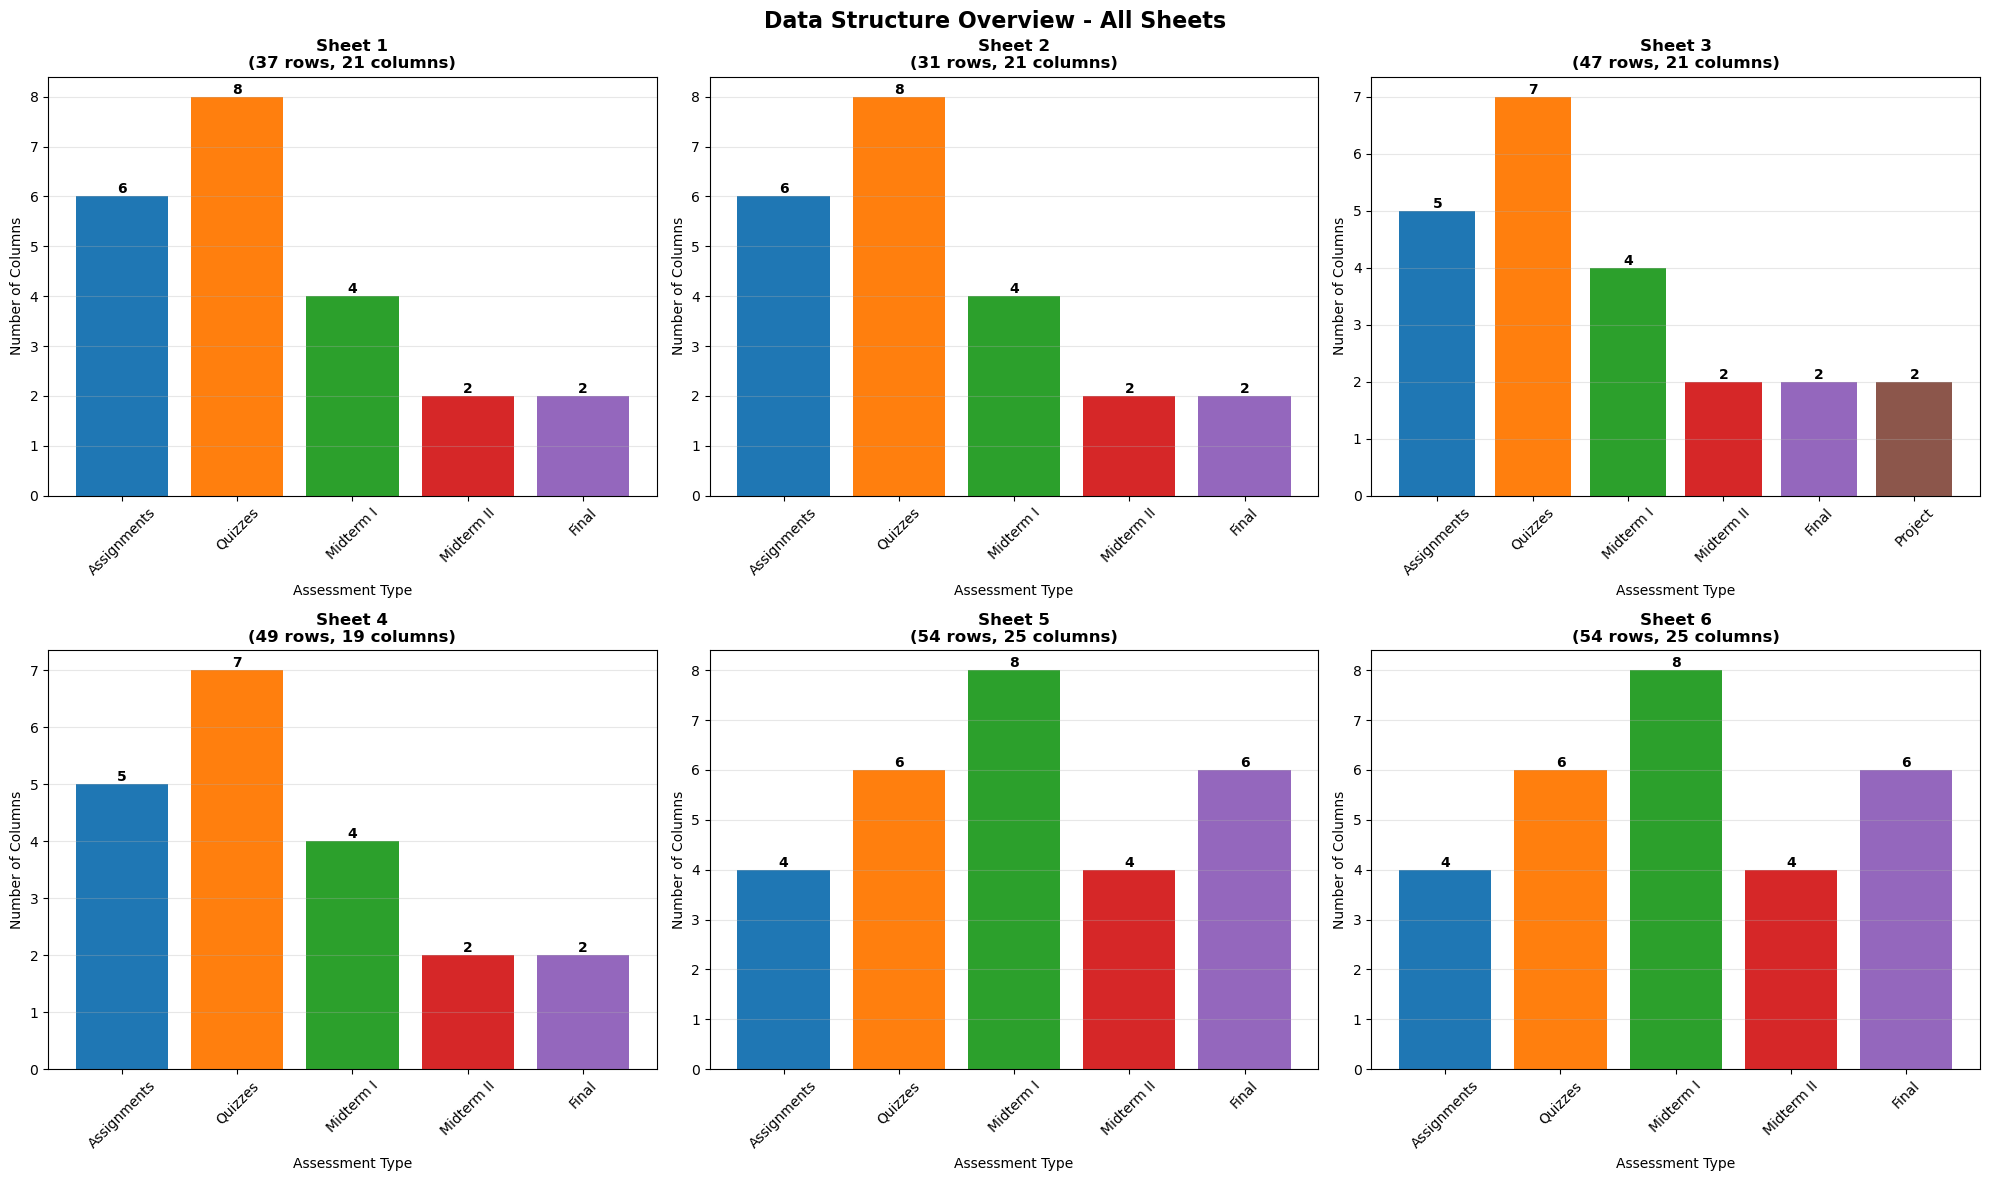

In [34]:
# ============================================================================
# VISUALIZE DATA STRUCTURE
# ============================================================================
print("\n" + "="*80)
print(" CREATING VISUALIZATION OF DATA STRUCTURE")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Data Structure Overview - All Sheets', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, (sheet_name, df) in enumerate(all_sheets.items()):
    ax = axes[idx]
    
    # Count different assessment types
    columns = df.columns.tolist()
    
    categories = {
        'Assignments': len([c for c in columns if 'As:' in c]),
        'Quizzes': len([c for c in columns if 'Qz:' in c]),
        'Midterm I': len([c for c in columns if 'S-I' in c]),
        'Midterm II': len([c for c in columns if 'S-II' in c]),
        'Final': len([c for c in columns if 'Final' in c]),
        'Project': len([c for c in columns if 'Proj' in c])
    }
    
    # Remove zero counts
    categories = {k: v for k, v in categories.items() if v > 0}
    
    # Create bar chart
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    bars = ax.bar(categories.keys(), categories.values(), color=colors[:len(categories)])
    
    ax.set_title(f'Sheet {sheet_name}\n({df.shape[0]} rows, {df.shape[1]} columns)',
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Columns', fontsize=10)
    ax.set_xlabel('Assessment Type', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}',
               ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Rotate x labels
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [36]:
# ============================================================================
# CREATE SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print(" SUMMARY TABLE")
print("="*80)

summary_data = []
for sheet_name, df in all_sheets.items():
    columns = df.columns.tolist()
    
    summary_data.append({
        'Sheet': sheet_name,
        'Total Rows': df.shape[0],
        'Total Columns': df.shape[1],
        'Students': df.shape[0] - 2,  # Excluding metadata rows
        'Assignments': len([c for c in columns if 'As:' in c]),
        'Quizzes': len([c for c in columns if 'Qz:' in c]),
        'Midterm I Cols': len([c for c in columns if 'S-I' in c]),
        'Midterm II Cols': len([c for c in columns if 'S-II' in c]),
        'Final Cols': len([c for c in columns if 'Final' in c]),
        'Has Project': 'Yes' if any('Proj' in c for c in columns) else 'No'
    })

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))



 SUMMARY TABLE

 Sheet  Total Rows  Total Columns  Students  Assignments  Quizzes  Midterm I Cols  Midterm II Cols  Final Cols Has Project
    1          37             21        35            6        8               4                2           2          No
    2          31             21        29            6        8               4                2           2          No
    3          47             21        45            5        7               4                2           2         Yes
    4          49             19        47            5        7               4                2           2          No
    5          54             25        52            4        6               8                4           6          No
    6          54             25        52            4        6               8                4           6          No


In [39]:
print("\n" + "="*80)
print(" KEY OBSERVATIONS")
print("="*80)

print("""
 DATA STRUCTURE CONFIRMED:

1. **Metadata Structure:**
   - Row 0: 'Weightage:' - percentage weights for each assessment
   - Row 1: 'Total' - maximum marks for each assessment
   - Row 2+: Actual student data

2. **Column Types:**
   - Raw scores: As:1, As:2, Qz:1, S-I:1, etc. (actual marks)
   - Weighted scores: S-I, S-II, Final (final grades)

3. **Target Variables for Prediction:**
   - RQ1: 'S-I' column (Weighted Midterm I)
   - RQ2: 'S-II' column (Weighted Midterm II)
   - RQ3: 'Final' column (Weighted Final exam)

4. **Total Students:**
   - Across all sheets: {} students

5. **Variations Between Sheets:**
   - Sheets 1-2: Have 8 quizzes, 6 assignments
   - Sheets 3-4: Have 7 quizzes, 5 assignments
   - Sheets 5-6: Have 6 quizzes, 4 assignments
   - Sheet 3: Unique - has Project component
   - Sheets 5-6: Multiple components for exams (S-I:1, S-I:2, S-I:3)

6. **Data Quality:**
   - Some missing values detected (NaN in weighted columns)
""".format(sum([df.shape[0] - 2 for df in all_sheets.values()])))

print("\n" + "="*80)
print(" STEP 1 COMPLETE - DATA STRUCTURE UNDERSTOOD!")
print("="*80)


 KEY OBSERVATIONS

 DATA STRUCTURE CONFIRMED:

1. **Metadata Structure:**
   - Row 0: 'Weightage:' - percentage weights for each assessment
   - Row 1: 'Total' - maximum marks for each assessment
   - Row 2+: Actual student data

2. **Column Types:**
   - Raw scores: As:1, As:2, Qz:1, S-I:1, etc. (actual marks)
   - Weighted scores: S-I, S-II, Final (final grades)

3. **Target Variables for Prediction:**
   - RQ1: 'S-I' column (Weighted Midterm I)
   - RQ2: 'S-II' column (Weighted Midterm II)
   - RQ3: 'Final' column (Weighted Final exam)

4. **Total Students:**
   - Across all sheets: 260 students

5. **Variations Between Sheets:**
   - Sheets 1-2: Have 8 quizzes, 6 assignments
   - Sheets 3-4: Have 7 quizzes, 5 assignments
   - Sheets 5-6: Have 6 quizzes, 4 assignments
   - Sheet 3: Unique - has Project component
   - Sheets 5-6: Multiple components for exams (S-I:1, S-I:2, S-I:3)

6. **Data Quality:**
   - Some missing values detected (NaN in weighted columns)


 STEP 1 COMPLETE - 

In [41]:
for name, df in all_sheets.items():
    print(f"\n===== SUMMARY FOR {name} =====")
    print("Shape:", df.shape)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nDescription:")
    display(df.describe())



===== SUMMARY FOR 1 =====
Shape: (37, 21)

Missing values:
 Unnamed: 0    0
As:1          1
As:2          1
As:3          1
As:4          1
As:5          3
As:6          5
Qz:1          1
Qz:2          2
Qz:3          1
Qz:4          1
Qz:5          2
Qz:6          4
Qz:7          4
Qz:8          4
S-I:1         1
S-I           2
S-II:1        1
S-II          2
Final:1       1
Final         2
dtype: int64

Description:


,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-I,S-II:1,S-II,Final:1,Final
count,36.000000,36.000000,36.000000,36.000000,34.000000,32.000000,36.000000,35.000000,36.000000,36.000000,35.000000,33.000000,33.000000,33.0,36.000000,35.000000,36.000000,35.000000,36.000000,35.000000
mean,81.583333,44.097222,52.694444,36.500000,80.088235,69.031250,3.277778,6.185714,3.000000,3.291667,3.542857,3.181818,5.757576,2.0,16.840278,6.330857,12.243333,4.557429,46.354167,20.872571
std,40.869391,24.885400,29.810180,11.593718,24.498136,20.271121,1.461137,2.910644,3.625308,4.427794,3.149163,1.362547,3.335700,0.0,6.825151,2.594403,8.213753,3.119882,18.350980,8.377815
min,0.000000,0.000000,0.000000,3.000000,3.000000,3.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.0,6.500000,2.430000,2.000000,0.750000,13.250000,5.960000
25%,69.875000,41.500000,39.375000,29.500000,62.875000,53.750000,2.500000,4.250000,0.500000,0.000000,1.000000,2.000000,3.000000,2.0,12.375000,4.590000,5.562500,2.010000,35.750000,16.080000
50%,99.000000,52.750000,60.750000,38.250000,82.750000,72.500000,3.500000,6.000000,1.250000,1.000000,3.000000,3.500000,5.000000,2.0,15.000000,5.620000,11.250000,4.120000,45.250000,20.470000
75%,108.250000,62.000000,76.375000,47.000000,93.750000,86.250000,4.500000,8.500000,4.375000,10.000000,5.750000,4.000000,9.000000,2.0,19.125000,7.215000,17.125000,6.465000,59.187500,26.825000
max,130.000000,70.000000,90.000000,50.000000,120.000000,90.000000,5.000000,15.000000,10.000000,10.000000,10.000000,5.000000,12.000000,2.0,40.000000,15.000000,40.000000,15.000000,100.000000,45.000000



===== SUMMARY FOR 2 =====
Shape: (31, 21)

Missing values:
 Unnamed: 0    0
As:1          2
As:2          1
As:3          2
As:4          1
As:5          2
As:6          4
Qz:1          1
Qz:2          4
Qz:3          4
Qz:4          1
Qz:5          4
Qz:6          4
Qz:7          5
Qz:8          2
S-I:1         1
S-I           2
S-II:1        2
S-II          3
Final:1       1
Final         2
dtype: int64

Description:


,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-I,S-II:1,S-II,Final:1,Final
count,29.000000,30.000000,29.000000,30.000000,29.000000,27.000000,30.000000,27.000000,27.000000,30.000000,27.000000,27.000000,26.000000,29.0,30.000000,29.000000,29.000000,28.000000,30.000000,29.000000
mean,60.827586,49.366667,66.827586,33.986667,87.379310,58.592593,2.783333,5.777778,1.592593,4.566667,2.962963,1.685185,8.538462,2.0,17.358333,6.535862,14.482759,5.420000,44.408333,19.970690
std,50.854884,23.762450,26.670381,12.361445,29.111134,17.653196,1.317543,2.577019,2.620324,4.005886,3.168128,1.594149,2.915212,0.0,8.453137,3.221873,9.136351,3.490452,19.245407,8.813696
min,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.0,2.500000,0.930000,1.250000,0.460000,5.500000,2.470000
25%,0.000000,50.500000,46.000000,24.250000,74.000000,52.500000,2.000000,4.500000,0.000000,2.000000,0.500000,0.500000,6.000000,2.0,12.500000,4.680000,7.250000,2.710000,36.375000,16.310000
50%,77.000000,58.500000,74.000000,34.500000,89.000000,57.000000,2.000000,5.000000,1.000000,2.000000,2.000000,1.500000,8.000000,2.0,15.000000,5.620000,11.500000,4.310000,43.750000,19.570000
75%,100.000000,64.750000,83.000000,45.000000,114.000000,72.000000,3.875000,6.500000,2.000000,10.000000,3.500000,2.000000,12.000000,2.0,21.625000,8.250000,19.500000,7.637500,51.187500,23.060000
max,130.000000,70.000000,100.000000,50.000000,120.000000,80.000000,5.000000,15.000000,10.000000,10.000000,10.000000,5.000000,12.000000,2.0,40.000000,15.000000,40.000000,15.000000,100.000000,45.000000



===== SUMMARY FOR 3 =====
Shape: (47, 21)

Missing values:
 Unnamed: 0     0
As:1           4
As:2           5
As:3           5
As:4           3
As:5           7
Qz:1           2
Qz:2           2
Qz:3           2
Qz:4           8
Qz:5           5
Qz:6          13
Qz:7          13
S-I:1          1
S-I            2
S-II:1         2
S-II           3
Proj:1         7
Proj           9
Final:1        1
Final          2
dtype: int64

Description:


...

,As:1,As:2,As:3,As:4,As:5,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,S-I:1,S-I,S-II:1,S-II,Final:1,Final
count,48.000000,48.000000,48.000000,44.000000,46.000000,45.000000,48.000000,47.000000,47.00000,45.000000,44.000000,43.000000,48.000000,47.000000,48.000000,47.000000,48.000000,47.000000
mean,57.421875,63.255208,76.144792,31.987500,51.961957,3.414667,5.815833,6.556596,5.40766,4.359111,5.299091,5.608372,18.791667,7.073830,20.861458,6.294681,40.463542,14.713404
std,17.721107,27.941118,37.869568,20.339022,25.320719,2.574163,3.548921,2.061685,2.96206,2.555842,3.164004,2.919518,8.489564,3.210879,12.276895,3.713577,19.506340,7.170840
min,3.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.660000,0.00000,0.000000,0.500000,0.000000,5.000000,1.870000,3.000000,0.900000,6.500000,2.360000
25%,37.000000,53.875000,68.250000,12.787500,43.875000,1.500000,3.375000,5.500000,3.00000,2.500000,2.000000,4.000000,11.875000,4.405000,10.250000,3.060000,25.187500,9.135000
50%,63.000000,68.750000,87.750000,38.000000,63.750000,2.500000,6.750000,6.500000,5.50000,4.500000,6.000000,5.000000,18.000000,6.750000,18.550000,5.700000,40.500000,14.900000
75%,70.250000,80.875000,103.625000,47.625000,71.125000,5.000000,9.500000,8.500000,8.00000,5.500000,8.000000,7.000000,26.000000,9.750000,30.825000,9.310000,53.000000,19.360000
max,80.000000,100.000000,120.000000,60.000000,80.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,12.000000,40.000000,15.000000,50.000000,15.000000,110.000000,40.000000



===== SUMMARY FOR 5 =====
Shape: (54, 25)

Missing values:
 Unnamed: 0    0
As:1          2
As:2          1
As:3          2
As:4          3
Qz:1          2
Qz:2          2
Qz:3          1
Qz:4          2
Qz:5          2
Qz:6          3
S-I:1         1
S-I:2         1
S-I:3         1
S-I           2
S-II:1        1
S-II:2        1
S-II:3        1
S-II          2
Final:1       1
Final:2       1
Final:3       1
Final:4       1
Final:5       1
Final         2
dtype: int64

Description:


,As:1,As:2,As:3,As:4,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,...,S-II:1,S-II:2,S-II:3,S-II,Final:1,Final:2,Final:3,Final:4,Final:5,Final
count,52.000000,53.000000,52.000000,51.000000,52.000000,52.000000,53.000000,52.000000,52.000000,51.000000,...,53.000000,53.000000,53.000000,52.000000,53.000000,53.000000,53.000000,53.000000,53.000000,52.000000
mean,46.060577,69.717925,70.254808,57.200980,3.730769,2.759615,6.113208,3.093462,4.846154,5.411765,...,11.093396,4.001698,12.131132,7.482115,29.771509,12.718868,9.739623,4.362264,6.869811,26.109615
std,24.766006,42.582722,17.900699,14.716659,3.216778,2.517566,3.693343,2.618035,3.022041,2.601357,...,5.283483,4.391881,5.246319,3.225257,7.688297,4.991957,3.982768,3.964711,5.143464,8.588126
min,0.000000,0.000000,3.250000,3.250000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.810000,13.000000,0.000000,0.000000,0.000000,0.000000,7.760000
25%,27.000000,25.800000,58.500000,53.000000,0.500000,0.750000,4.000000,1.000000,2.000000,4.000000,...,8.000000,1.000000,8.000000,5.040000,24.000000,11.000000,7.000000,1.000000,2.500000,18.712500
50%,40.750000,88.000000,74.000000,59.000000,3.500000,2.000000,6.000000,2.000000,5.000000,6.000000,...,11.000000,2.000000,12.500000,7.220000,32.500000,13.000000,10.500000,3.000000,6.000000,27.580000
75%,65.500000,102.000000,86.000000,66.500000,6.000000,5.000000,8.000000,5.000000,7.000000,7.000000,...,15.000000,5.000000,16.500000,9.852500,36.000000,16.000000,12.500000,7.000000,9.500000,31.235000
max,100.000000,120.000000,100.000000,80.000000,10.000000,10.000000,16.000000,10.000000,10.000000,10.000000,...,20.000000,15.000000,20.000000,15.000000,40.000000,20.000000,15.000000,15.000000,20.000000,45.000000



===== SUMMARY FOR 6 =====
Shape: (54, 25)

Missing values:
 Unnamed: 0    0
As:1          4
As:2          4
As:3          3
As:4          5
Qz:1          2
Qz:2          1
Qz:3          1
Qz:4          2
Qz:5          7
Qz:6          6
S-I:1         1
S-I:2         1
S-I:3         1
S-I           2
S-II:1        1
S-II:2        1
S-II:3        1
S-II          3
Final:1       1
Final:2       1
Final:3       1
Final:4       1
Final:5       1
Final         2
dtype: int64

Description:


,As:1,As:2,As:3,As:4,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,...,S-II:1,S-II:2,S-II:3,S-II,Final:1,Final:2,Final:3,Final:4,Final:5,Final
count,50.000000,50.000000,51.000000,49.000000,52.000000,53.000000,53.000000,52.000000,47.000000,48.000000,...,53.000000,53.000000,53.000000,51.000000,53.000000,53.000000,53.000000,53.000000,53.000000,52.000000
mean,49.225000,67.245000,63.573529,49.596939,4.269231,1.849057,3.528302,3.673077,1.904255,3.447917,...,10.951887,3.096038,11.244340,7.080196,28.592264,10.209434,8.522642,4.093396,5.728302,23.483077
std,19.398628,36.033732,25.639925,28.727383,2.933013,2.589893,1.384721,3.035549,2.349001,2.664262,...,5.652909,3.595401,5.840654,3.104782,8.741700,4.727752,4.551020,4.011259,4.694161,8.938085
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.310000,8.500000,1.000000,0.000000,0.000000,0.000000,6.050000
25%,37.125000,65.500000,50.000000,37.000000,1.875000,0.000000,2.500000,0.000000,0.000000,1.375000,...,6.000000,1.000000,6.500000,4.630000,20.500000,7.000000,6.000000,1.000000,2.500000,16.615000
50%,48.000000,79.000000,69.000000,62.000000,5.000000,0.000000,3.500000,4.250000,1.000000,3.000000,...,12.000000,2.000000,11.500000,7.080000,31.000000,10.000000,9.000000,2.500000,4.500000,23.455000
75%,60.875000,91.000000,81.500000,71.000000,6.000000,3.000000,4.500000,6.000000,3.000000,5.000000,...,15.000000,4.000000,15.000000,8.720000,36.000000,13.000000,12.500000,6.000000,8.000000,30.105000
max,100.000000,120.000000,100.000000,80.000000,10.000000,10.000000,8.000000,10.000000,10.000000,10.000000,...,20.000000,15.000000,20.000000,15.000000,40.000000,20.000000,15.000000,15.000000,20.000000,45.000000



===== Distribution Plots for 1 =====


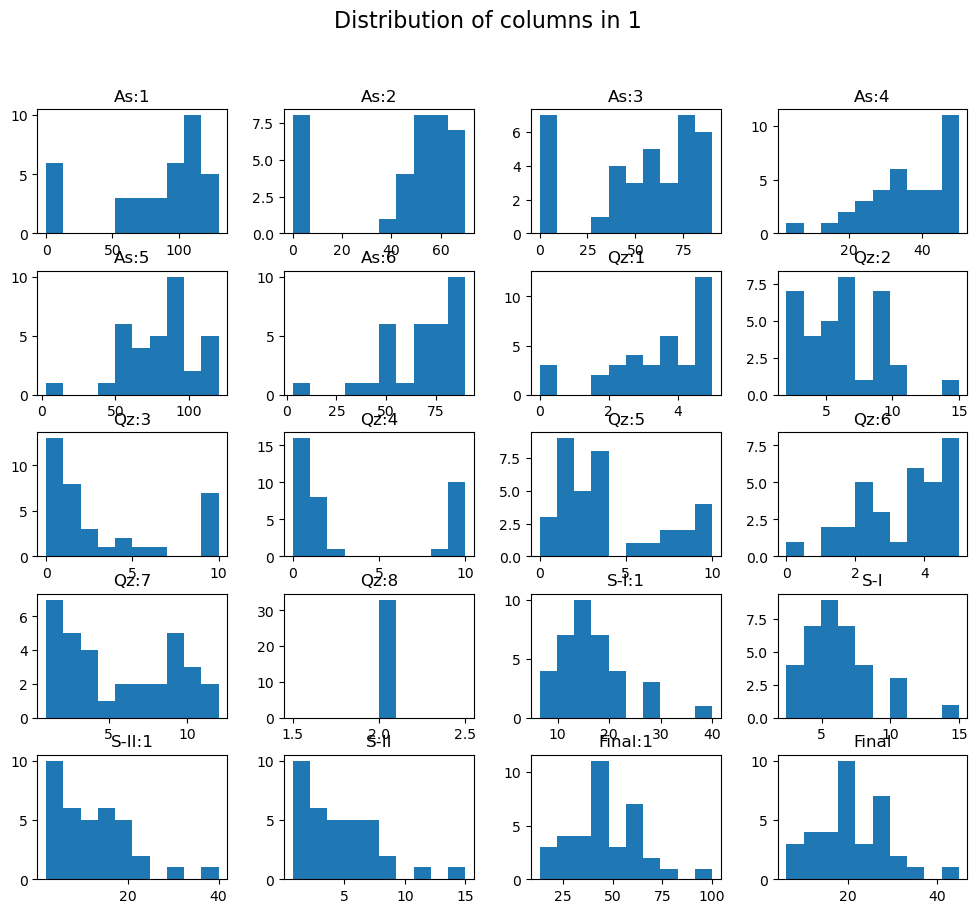


===== Distribution Plots for 2 =====


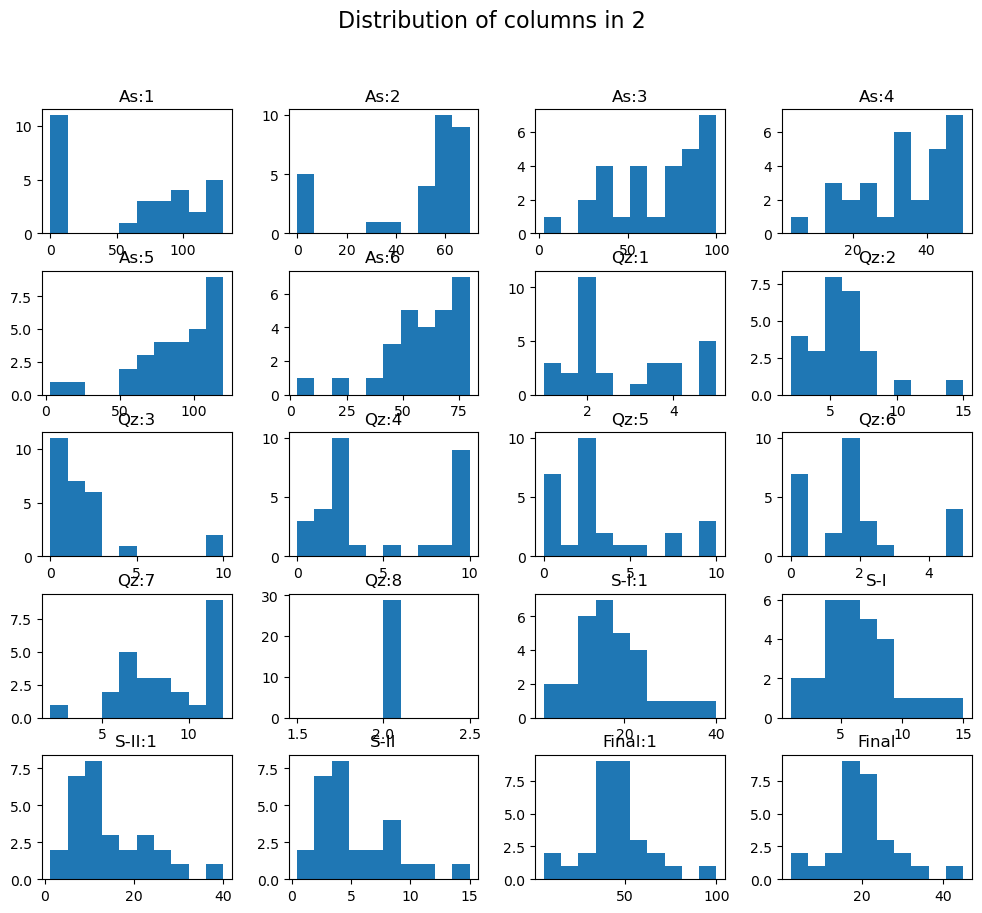


===== Distribution Plots for 3 =====


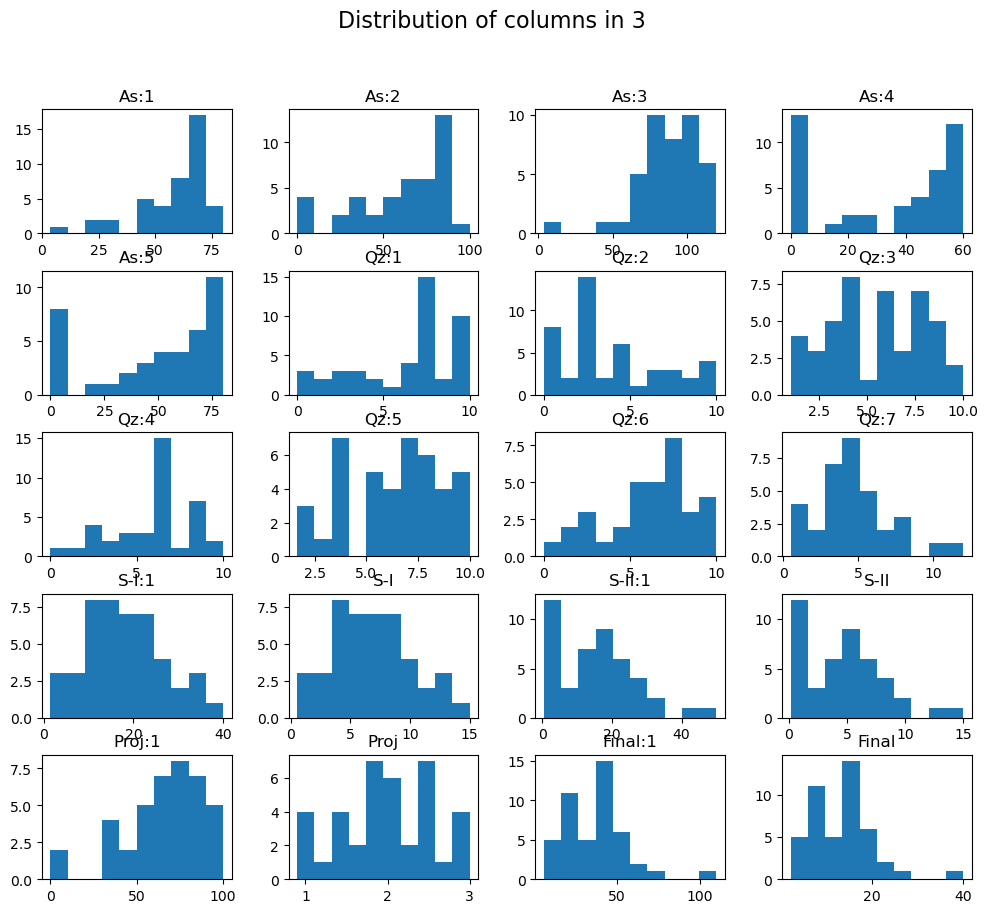


===== Distribution Plots for 4 =====


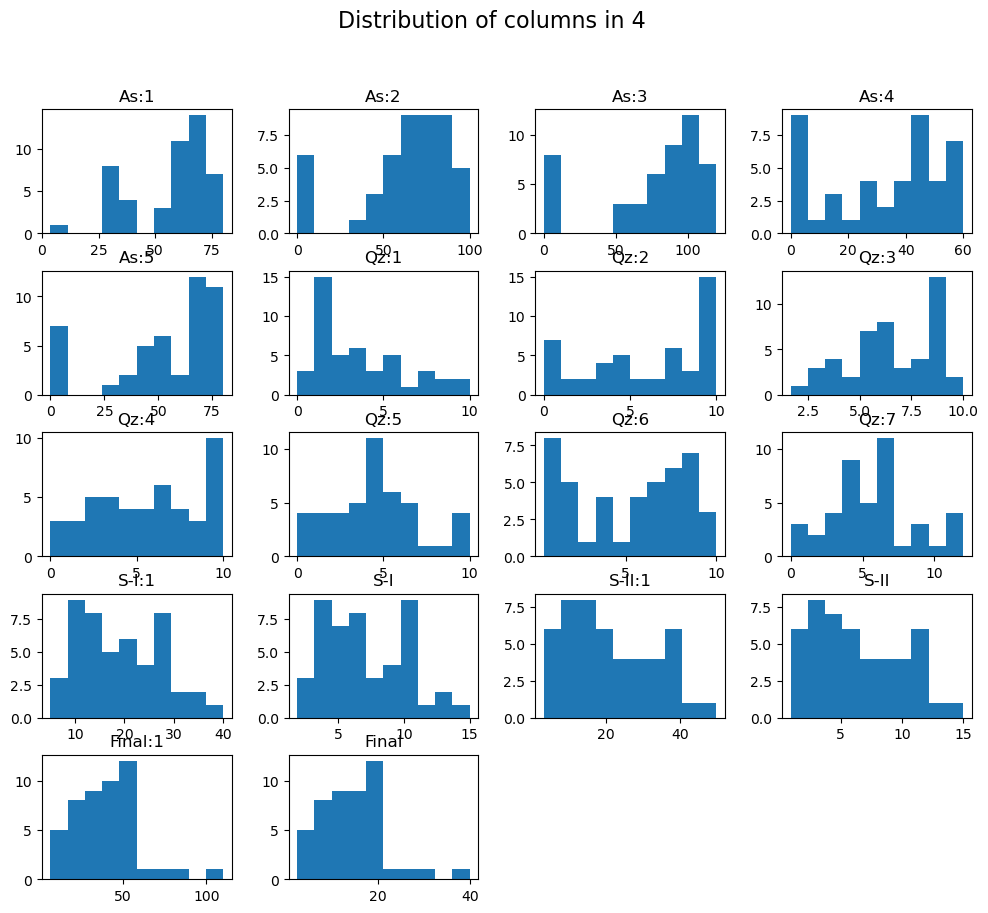


===== Distribution Plots for 5 =====


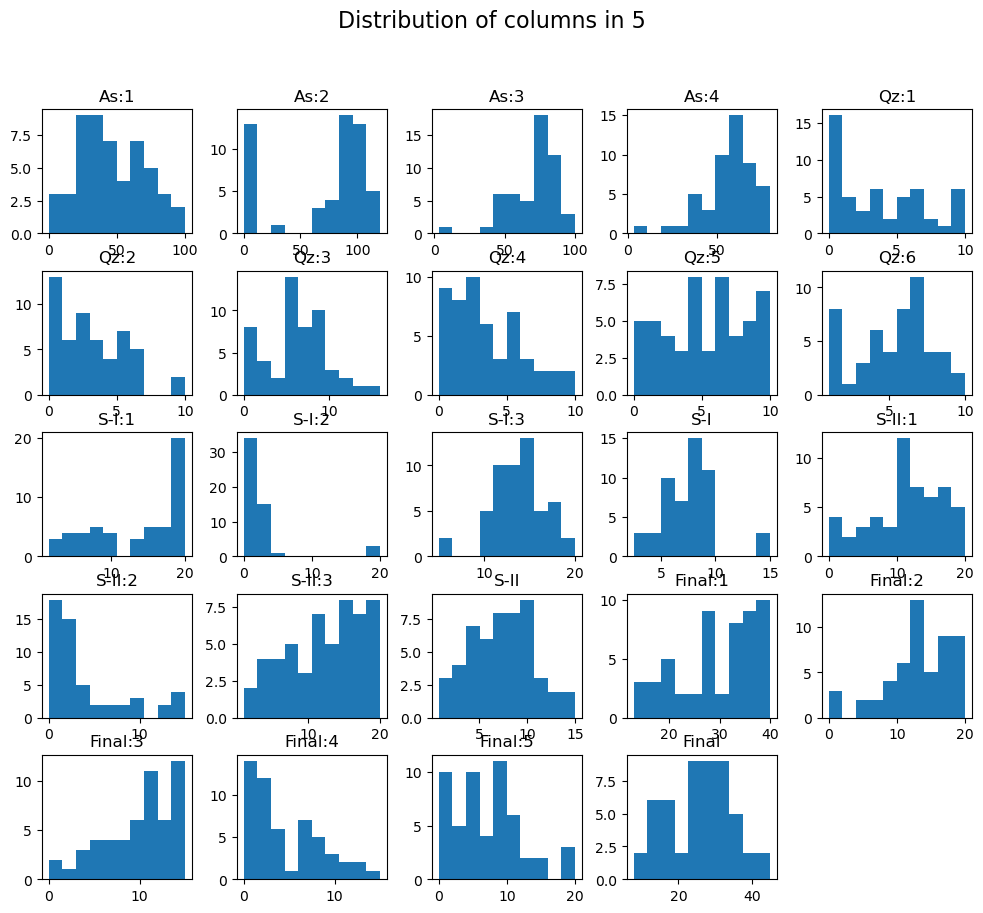


===== Distribution Plots for 6 =====


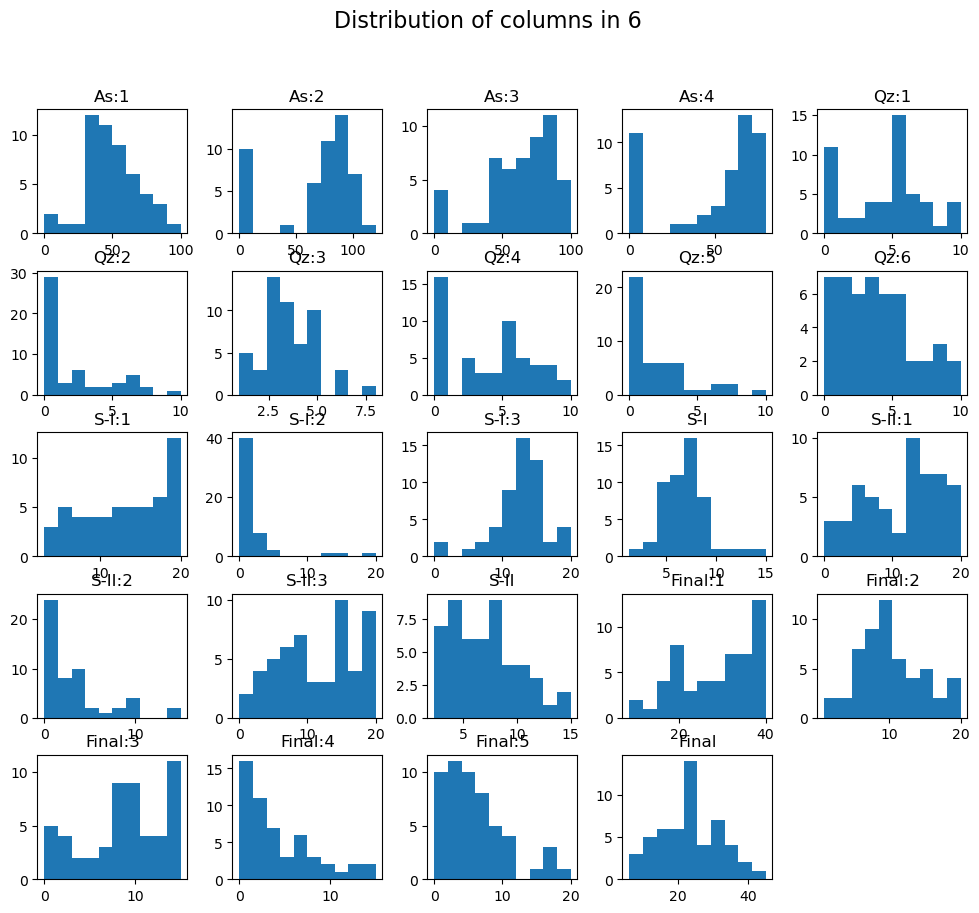

In [42]:
import matplotlib.pyplot as plt

for name, df in all_sheets.items():
    print(f"\n===== Distribution Plots for {name} =====")
    df.hist(figsize=(12, 10), grid=False)
    plt.suptitle(f"Distribution of columns in {name}", fontsize=16)
    plt.show()



===== Correlation Heatmap for 1 =====


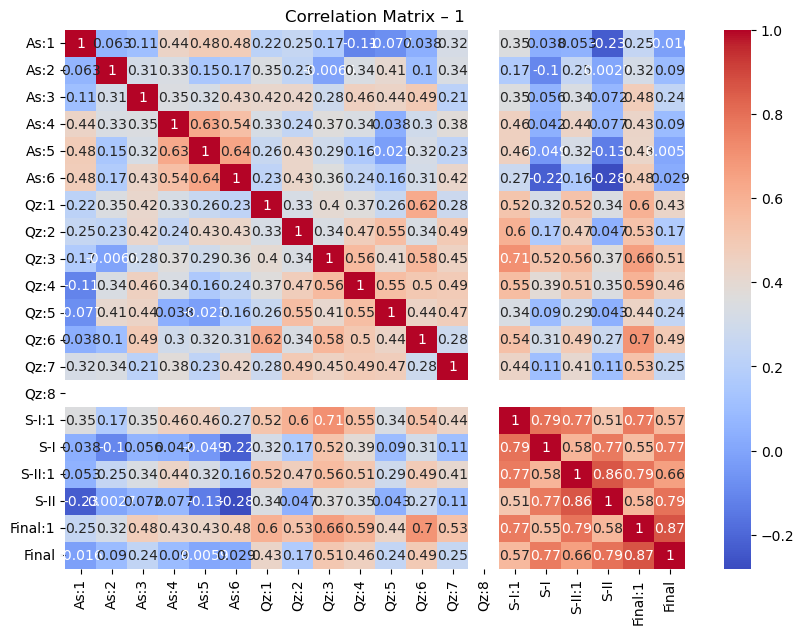


===== Correlation Heatmap for 2 =====


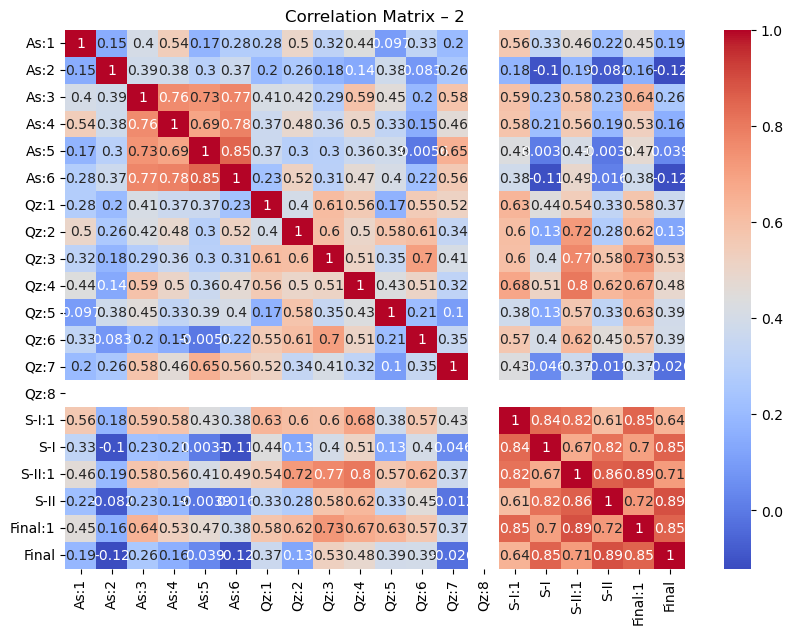


===== Correlation Heatmap for 3 =====


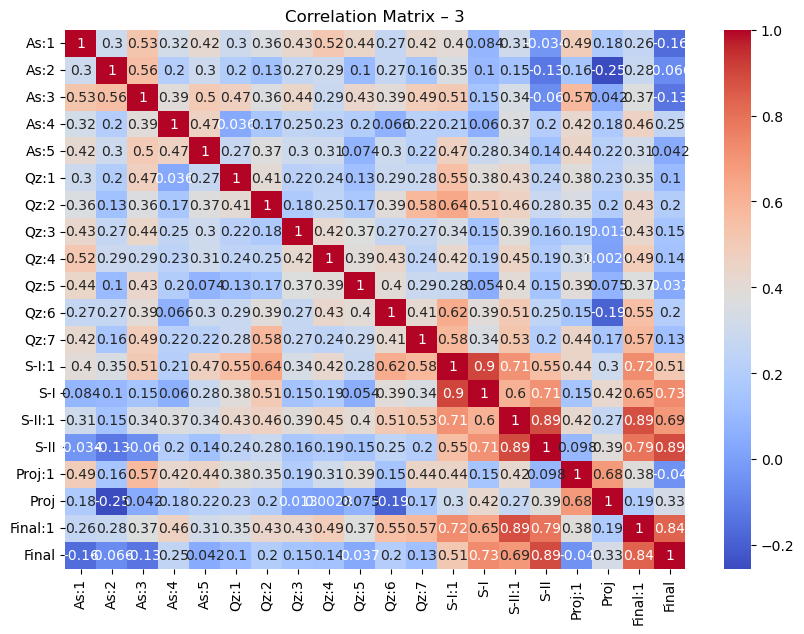


===== Correlation Heatmap for 4 =====


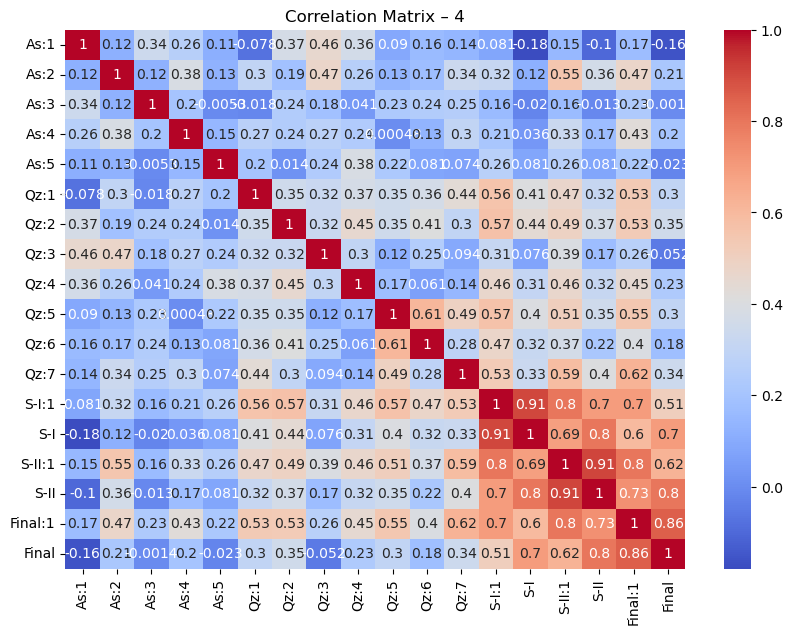


===== Correlation Heatmap for 5 =====


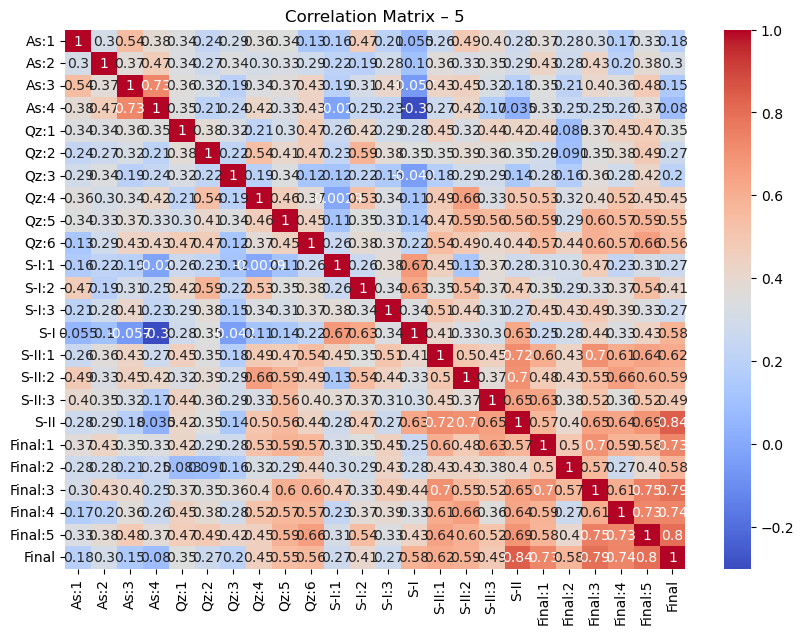


===== Correlation Heatmap for 6 =====


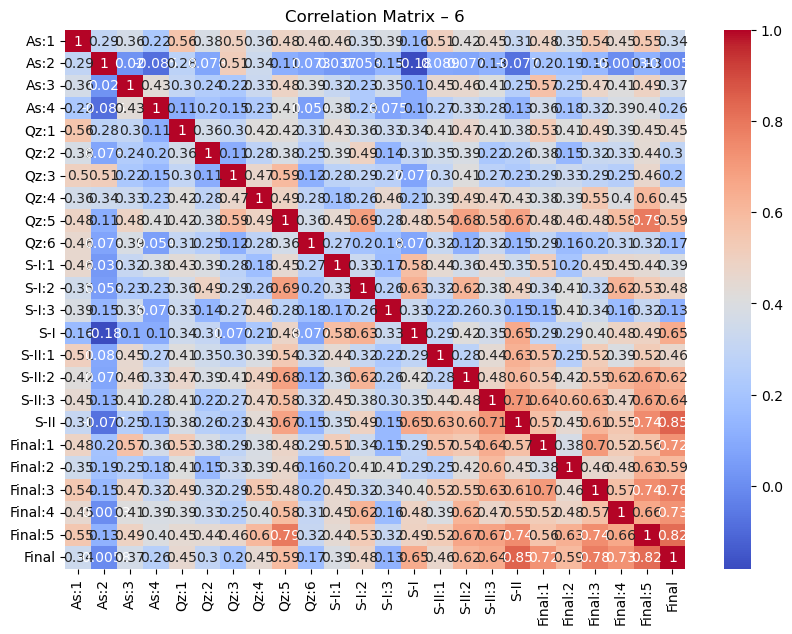

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, df in all_sheets.items():
    print(f"\n===== Correlation Heatmap for {name} =====")
    plt.figure(figsize=(10, 7))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
    plt.title(f"Correlation Matrix – {name}")
    plt.show()


In [47]:
common_cols = set.intersection(*(set(df.columns) for df in all_sheets.values()))
common_cols


{'As:1',
 'As:2',
 'As:3',
 'As:4',
 'Final',
 'Final:1',
 'Qz:1',
 'Qz:2',
 'Qz:3',
 'Qz:4',
 'Qz:5',
 'Qz:6',
 'S-I',
 'S-I:1',
 'S-II',
 'S-II:1',
 'Unnamed: 0'}

In [48]:
unique_cols = {name: set(df.columns) for name, df in all_sheets.items()}
unique_cols


{'1': {'As:1',
  'As:2',
  'As:3',
  'As:4',
  'As:5',
  'As:6',
  'Final',
  'Final:1',
  'Qz:1',
  'Qz:2',
  'Qz:3',
  'Qz:4',
  'Qz:5',
  'Qz:6',
  'Qz:7',
  'Qz:8',
  'S-I',
  'S-I:1',
  'S-II',
  'S-II:1',
  'Unnamed: 0'},
 '2': {'As:1',
  'As:2',
  'As:3',
  'As:4',
  'As:5',
  'As:6',
  'Final',
  'Final:1',
  'Qz:1',
  'Qz:2',
  'Qz:3',
  'Qz:4',
  'Qz:5',
  'Qz:6',
  'Qz:7',
  'Qz:8',
  'S-I',
  'S-I:1',
  'S-II',
  'S-II:1',
  'Unnamed: 0'},
 '3': {'As:1',
  'As:2',
  'As:3',
  'As:4',
  'As:5',
  'Final',
  'Final:1',
  'Proj',
  'Proj:1',
  'Qz:1',
  'Qz:2',
  'Qz:3',
  'Qz:4',
  'Qz:5',
  'Qz:6',
  'Qz:7',
  'S-I',
  'S-I:1',
  'S-II',
  'S-II:1',
  'Unnamed: 0'},
 '4': {'As:1',
  'As:2',
  'As:3',
  'As:4',
  'As:5',
  'Final',
  'Final:1',
  'Qz:1',
  'Qz:2',
  'Qz:3',
  'Qz:4',
  'Qz:5',
  'Qz:6',
  'Qz:7',
  'S-I',
  'S-I:1',
  'S-II',
  'S-II:1',
  'Unnamed: 0'},
 '5': {'As:1',
  'As:2',
  'As:3',
  'As:4',
  'Final',
  'Final:1',
  'Final:2',
  'Final:3',
  'Final:4'